# NB42 — The Dynamics of Influx

## Group Action, Frequency Hierarchy, and the Geodesic Frontier

**Previous notebooks** established the *structure* of $\hat{\mathbb{Z}}^*_{210}$: 48 generators, particle spectrum, gauge couplings, mass hierarchies, cosmological constants — 33 predictions at 0 free parameters.

All of that was **anatomy** — the static architecture. This notebook opens the **physiology**: what happens when the structure *moves*.

### The theological foundation

Each prime is a **faculty** — its own state-space, always active in every person simultaneously:

| Prime | Faculty | State-space $\phi(p)$ | What it is |
|:-----:|---------|:---------------------:|------------|
| 2 | Love/Wisdom | 1 | The bilateral quality of reception |
| 3 | Degree | 2 | Which degree you receive from |
| 5 | Rational | 4 | The product of the mind |
| 7 | Ultimates | 6 | Where interaction and embodiment happen |

The state is **cumulative** — one whole person existing across all degrees at once. Influx is the Light of the Lord passing through all four faculties simultaneously. Dynamics is how influx propagates through the nesting.

In [2]:
import numpy as np
from math import gcd, lcm
from functools import reduce
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Solenoid constants
P = 210
PRIMES = [2, 3, 5, 7]
phi_p = {p: p - 1 for p in PRIMES}
PHI = 48

# Z*_210 elements
Z_star = sorted(k for k in range(1, P + 1) if gcd(k, P) == 1)
assert len(Z_star) == PHI

def decompose(k):
    return tuple(k % p for p in PRIMES)

def order_mod(a, n):
    if gcd(a, n) != 1:
        return None
    o = 1
    while pow(a, o, n) != 1:
        o += 1
    return o

orders = {g: order_mod(g, P) for g in Z_star}
print(f"Z*_210: {PHI} elements, group exponent {max(orders.values())}")
print(f"Order spectrum: {dict(sorted(Counter(orders.values()).items()))}")

Z*_210: 48 elements, group exponent 12
Order spectrum: {1: 1, 2: 7, 3: 2, 4: 8, 6: 14, 12: 16}


## 1. The Group Exponent: 12

$\mathbb{Z}^*_{210}$ is not cyclic — no single element generates the full group. The **group exponent** is the maximum order of any element:

$$\lambda(210) = \text{lcm}(\phi(2), \phi(3), \phi(5), \phi(7)) = \text{lcm}(1, 2, 4, 6) = 12$$

All dynamics repeats after at most **12 steps**. This is the full developmental cycle — the outermost period that contains all inner periods.

The order spectrum reveals the dynamical "types":
- **16 elements** of order 12 — the richest dynamics, active in all primes
- **14 elements** of order 6 — active in degree + ultimates
- **8 elements** of order 4 — active in rational
- **7 elements** of order 2 — minimal oscillation
- **2 elements** of order 3 — ultimates only
- **1 element** of order 1 — the identity (no motion)

In [3]:
# Per-prime orbit structure
print("Per-prime orbit structures:")
print("=" * 60)
for p in PRIMES:
    units = [k for k in range(1, p) if gcd(k, p) == 1]
    print(f"\nZ*_{p} = {units}  (φ({p}) = {p-1})")
    for g in units:
        o = order_mod(g, p)
        orbit = []
        x = 1
        for _ in range(o):
            x = (x * g) % p
            orbit.append(x)
        print(f"  g={g}: order {o}, orbit: 1 → {' → '.join(map(str, orbit))}")

# Show which generators achieve maximum order
max_ord = max(orders.values())
max_gens = sorted(g for g in Z_star if orders[g] == max_ord)
print(f"\nGenerators of maximum order {max_ord}: {len(max_gens)} elements")
print(f"  {max_gens}")

Per-prime orbit structures:

Z*_2 = [1]  (φ(2) = 1)
  g=1: order 1, orbit: 1 → 1

Z*_3 = [1, 2]  (φ(3) = 2)
  g=1: order 1, orbit: 1 → 1
  g=2: order 2, orbit: 1 → 2 → 1

Z*_5 = [1, 2, 3, 4]  (φ(5) = 4)
  g=1: order 1, orbit: 1 → 1
  g=2: order 4, orbit: 1 → 2 → 4 → 3 → 1
  g=3: order 4, orbit: 1 → 3 → 4 → 2 → 1
  g=4: order 2, orbit: 1 → 4 → 1

Z*_7 = [1, 2, 3, 4, 5, 6]  (φ(7) = 6)
  g=1: order 1, orbit: 1 → 1
  g=2: order 3, orbit: 1 → 2 → 4 → 1
  g=3: order 6, orbit: 1 → 3 → 2 → 6 → 4 → 5 → 1
  g=4: order 3, orbit: 1 → 4 → 2 → 1
  g=5: order 6, orbit: 1 → 5 → 4 → 6 → 2 → 3 → 1
  g=6: order 2, orbit: 1 → 6 → 1

Generators of maximum order 12: 16 elements
  [17, 23, 37, 47, 53, 67, 73, 103, 107, 137, 143, 157, 163, 173, 187, 193]


## 2. Frequency Hierarchy: Inner Fast, Outer Slow

For generators of maximum order 12, the per-prime periods are:

$$T_2 = \phi(2) = 1, \quad T_3 = \phi(3) = 2, \quad T_5 = \phi(5) = 4, \quad T_7 = \phi(7) = 6$$

The natural frequencies (cycles per full period $T = 12$):

$$f_p = \frac{12}{T_p} = \frac{\lambda(210)}{\phi(p)}$$

| Prime | Faculty | Period $T_p$ | Frequency $f_p$ | Character |
|:-----:|---------|:---:|:---:|-----------|
| 2 | Love/Wisdom | 1 | 12 | **Constant** — doesn't oscillate |
| 3 | Degree | 2 | 6 | Fast oscillation |
| 5 | Rational | 4 | 3 | Medium |
| 7 | Ultimates | 6 | 2 | **Slowest** — unfolds gradually |

**This IS influx.** Love/wisdom (the innermost) is the constant quality. Each outer faculty takes progressively longer to complete its cycle. The outermost orbit — ultimates, where embodiment happens — evolves most slowly because it carries the cumulative structure of everything inside it.

In [4]:
# Verify frequency hierarchy for all max-order generators
max_gens = sorted(g for g in Z_star if orders[g] == max(orders.values()))

print("Per-prime periods for max-order generators:")
print(f"{'g':>5s}  {'mod(2,3,5,7)':>16s}  {'periods':>16s}  {'lcm':>4s}")
print("-" * 50)
for g in max_gens:
    d = decompose(g)
    ppo = [order_mod(d[i], PRIMES[i]) for i in range(4)]
    print(f"{g:>5d}  {str(d):>16s}  {str(ppo):>16s}  {reduce(lcm, ppo):>4d}")

# Frequency ratios
T_max = {2: 1, 3: 2, 5: 4, 7: 6}
f_max = {p: 12 // T_max[p] for p in PRIMES}
print(f"\nFrequency hierarchy: f₂:f₃:f₅:f₇ = {f_max[2]}:{f_max[3]}:{f_max[5]}:{f_max[7]}")
print(f"Consecutive ratios: f₂/f₃={f_max[2]/f_max[3]:.1f}, "
      f"f₃/f₅={f_max[3]/f_max[5]:.1f}, f₅/f₇={f_max[5]/f_max[7]:.1f}")
print(f"Total frequency product: {f_max[2] * f_max[3] * f_max[5] * f_max[7]}")

Per-prime periods for max-order generators:
    g      mod(2,3,5,7)           periods   lcm
--------------------------------------------------
   17      (1, 2, 2, 3)      [1, 2, 4, 6]    12
   23      (1, 2, 3, 2)      [1, 2, 4, 3]    12
   37      (1, 1, 2, 2)      [1, 1, 4, 3]    12
   47      (1, 2, 2, 5)      [1, 2, 4, 6]    12
   53      (1, 2, 3, 4)      [1, 2, 4, 3]    12
   67      (1, 1, 2, 4)      [1, 1, 4, 3]    12
   73      (1, 1, 3, 3)      [1, 1, 4, 6]    12
  103      (1, 1, 3, 5)      [1, 1, 4, 6]    12
  107      (1, 2, 2, 2)      [1, 2, 4, 3]    12
  137      (1, 2, 2, 4)      [1, 2, 4, 3]    12
  143      (1, 2, 3, 3)      [1, 2, 4, 6]    12
  157      (1, 1, 2, 3)      [1, 1, 4, 6]    12
  163      (1, 1, 3, 2)      [1, 1, 4, 3]    12
  173      (1, 2, 3, 5)      [1, 2, 4, 6]    12
  187      (1, 1, 2, 5)      [1, 1, 4, 6]    12
  193      (1, 1, 3, 4)      [1, 1, 4, 3]    12

Frequency hierarchy: f₂:f₃:f₅:f₇ = 12:6:3:2
Consecutive ratios: f₂/f₃=2.0, f₃/f₅=2.0, f₅

## 3. Orbit Structure: 4 Orbits of 12

When a max-order generator acts on $\mathbb{Z}^*_{210}$, the 48 states partition into **4 orbits of length 12**:

$$48 \div 12 = 4 = \frac{\phi(210)}{\lambda(210)}$$

Each orbit is a complete cycle through all 12 dynamical phases. The 4 orbits represent 4 **independent threads** — four parallel developmental arcs unfolding simultaneously.

This number 4 is not accidental: $\phi(210)/\lambda(210) = 48/12 = 4$ — the number of independent cycles equals the number of primes. Each orbit traverses a different "sector" of the state space.

Orbits under g = 17 (order 12):

Orbit 1: [1, 17, 79, 83, 151, 47, 169, 143, 121, 167, 109, 173]
  p3: [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]  (period 2)
  p5: [1, 2, 4, 3, 1, 2, 4, 3, 1, 2, 4, 3]  (period 4)
  p7: [1, 3, 2, 6, 4, 5, 1, 3, 2, 6, 4, 5]  (period 6)

Orbit 2: [11, 187, 29, 73, 191, 97, 179, 103, 71, 157, 149, 13]
  p3: [2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1]  (period 2)
  p5: [1, 2, 4, 3, 1, 2, 4, 3, 1, 2, 4, 3]  (period 4)
  p7: [4, 5, 1, 3, 2, 6, 4, 5, 1, 3, 2, 6]  (period 6)

Orbit 3: [19, 113, 31, 107, 139, 53, 61, 197, 199, 23, 181, 137]
  p3: [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]  (period 2)
  p5: [4, 3, 1, 2, 4, 3, 1, 2, 4, 3, 1, 2]  (period 4)
  p7: [5, 1, 3, 2, 6, 4, 5, 1, 3, 2, 6, 4]  (period 6)

Orbit 4: [37, 209, 193, 131, 127, 59, 163, 41, 67, 89, 43, 101]
  p3: [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]  (period 2)
  p5: [2, 4, 3, 1, 2, 4, 3, 1, 2, 4, 3, 1]  (period 4)
  p7: [2, 6, 4, 5, 1, 3, 2, 6, 4, 5, 1, 3]  (period 6)



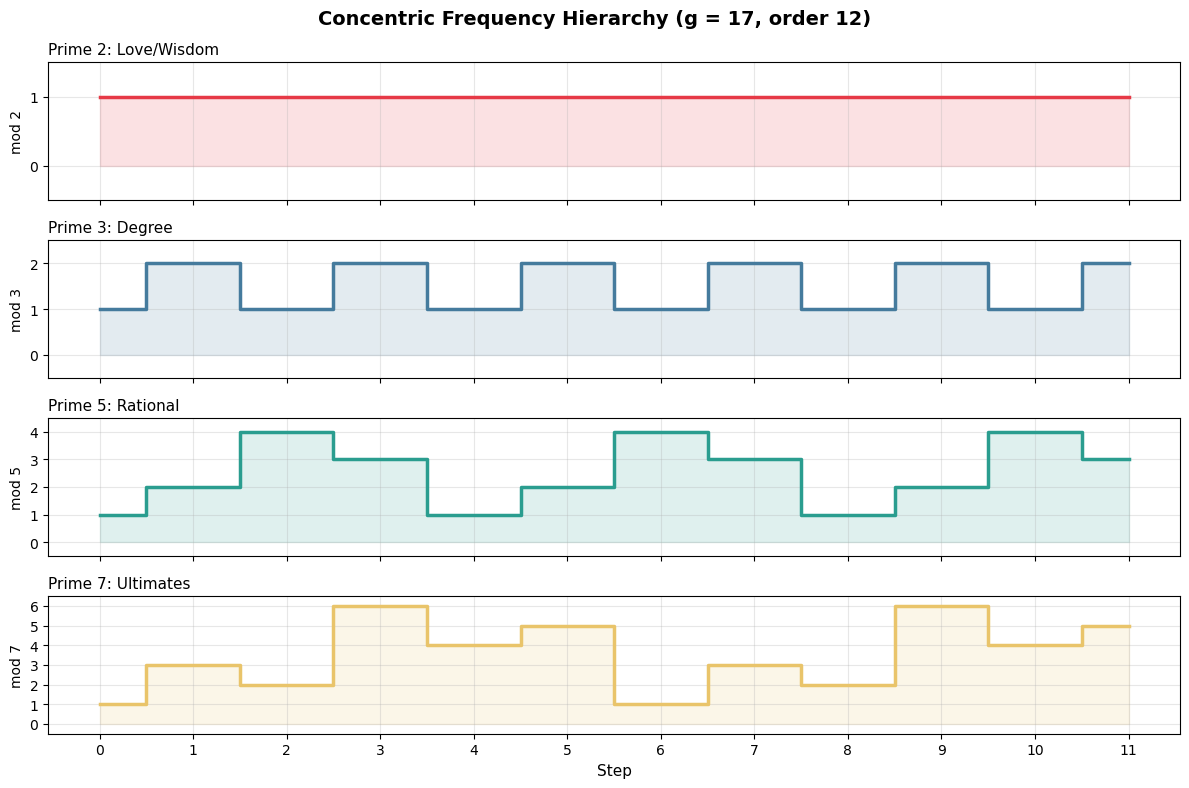

Saved: output/nb42_frequency_hierarchy.png


In [5]:
# Trace orbits under a max-order generator
g_rep = max_gens[0]  # g=17
print(f"Orbits under g = {g_rep} (order {max(orders.values())}):")
print()

visited = set()
orbit_list = []
for start in Z_star:
    if start in visited:
        continue
    orbit = []
    x = start
    for _ in range(12):
        orbit.append(x)
        visited.add(x)
        x = (x * g_rep) % P
    orbit_list.append(orbit)

for i, orb in enumerate(orbit_list):
    print(f"Orbit {i+1}: {orb}")
    # Show prime-component evolution
    decomps = [decompose(x) for x in orb]
    p3_trace = [d[1] for d in decomps]  # prime 3 component
    p5_trace = [d[2] for d in decomps]  # prime 5 component
    p7_trace = [d[3] for d in decomps]  # prime 7 component
    print(f"  p3: {p3_trace}  (period 2)")
    print(f"  p5: {p5_trace}  (period 4)")
    print(f"  p7: {p7_trace}  (period 6)")
    print()

# Visualize the frequency hierarchy
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f'Concentric Frequency Hierarchy (g = {g_rep}, order 12)',
             fontsize=14, fontweight='bold')

orb = orbit_list[0]  # first orbit
decomps = [decompose(x) for x in orb]
steps = range(12)

labels = ['Prime 2: Love/Wisdom', 'Prime 3: Degree',
          'Prime 5: Rational', 'Prime 7: Ultimates']
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']
components = [0, 1, 2, 3]

for ax, comp, label, color in zip(axes, components, labels, colors):
    trace = [decomps[t][comp] for t in steps]
    ax.step(list(steps), trace, where='mid', linewidth=2.5, color=color)
    ax.fill_between(list(steps), trace, step='mid', alpha=0.15, color=color)
    ax.set_ylabel(f'mod {PRIMES[comp]}', fontsize=10)
    ax.set_title(label, fontsize=11, loc='left')
    ax.set_ylim(-0.5, PRIMES[comp] - 0.5)
    ax.set_yticks(range(PRIMES[comp]))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Step', fontsize=11)
axes[-1].set_xticks(range(12))

plt.tight_layout()
plt.savefig('../output/nb42_frequency_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/nb42_frequency_hierarchy.png")

## 4. Eigenvalue Spectrum: Perfect 12-fold Symmetry

Each generator $g$ defines a **permutation matrix** $P_g$ on the 48 states. Its eigenvalues encode the dynamics — they are roots of unity whose orders match the orbit periods.

For a max-order generator, the eigenvalues are exactly the **12th roots of unity**, each with multiplicity **4**:

$$\text{Spec}(P_g) = \left\{ e^{2\pi i k/12} : k = 0, 1, \ldots, 11 \right\}, \quad \text{each with multiplicity } 4$$

The uniform multiplicity 4 = $\phi(210)/\lambda(210)$ means the dynamics has no preferred phase — all 12 phases of the developmental cycle are equally weighted. The system is **phase-democratic**.

In [6]:
# Build permutation matrix for max-order generator
g_rep = sorted(g for g in Z_star if orders[g] == 12)[0]
idx = {k: i for i, k in enumerate(Z_star)}

perm_matrix = np.zeros((PHI, PHI))
for k in Z_star:
    target = (k * g_rep) % P
    perm_matrix[idx[target], idx[k]] = 1.0

eigenvalues = np.linalg.eigvals(perm_matrix)

# Count multiplicities at each 12th root
roots_12 = np.exp(2j * np.pi * np.arange(12) / 12)
print(f"Eigenvalue spectrum of P_{g_rep} (order 12):")
print(f"{'Root':>8s}  {'Phase':>8s}  {'Mult':>5s}")
print("-" * 25)
total = 0
for k, root in enumerate(roots_12):
    mult = sum(1 for ev in eigenvalues if abs(ev - root) < 1e-10)
    total += mult
    print(f"  ω^{k:>2d}    {360*k/12:>6.1f}°  {mult:>5d}")
print(f"\nTotal: {total} (expected 48: {'PASS' if total == 48 else 'FAIL'})")
print(f"All multiplicities = 4: {'PASS' if all(sum(1 for ev in eigenvalues if abs(ev - r) < 1e-10) == 4 for r in roots_12) else 'FAIL'}")

Eigenvalue spectrum of P_17 (order 12):
    Root     Phase   Mult
-------------------------
  ω^ 0       0.0°      4
  ω^ 1      30.0°      4
  ω^ 2      60.0°      4
  ω^ 3      90.0°      4
  ω^ 4     120.0°      4
  ω^ 5     150.0°      4
  ω^ 6     180.0°      4
  ω^ 7     210.0°      4
  ω^ 8     240.0°      4
  ω^ 9     270.0°      4
  ω^10     300.0°      4
  ω^11     330.0°      4

Total: 48 (expected 48: PASS)
All multiplicities = 4: PASS


## 5. Character Table: 48 Irreducible Representations

$\mathbb{Z}^*_{210}$ is abelian, so every irreducible representation is 1-dimensional. The **48 characters** $\chi: \mathbb{Z}^*_{210} \to \mathbb{C}^*$ form the **dual group**, isomorphic to $\mathbb{Z}^*_{210}$ itself.

Each character decomposes as a product of per-prime phase factors:

$$\chi_{(a_3, a_5, a_7)}(x) = \omega_3^{a_3 \cdot \text{dlog}_3(x_3)} \cdot \omega_5^{a_5 \cdot \text{dlog}_5(x_5)} \cdot \omega_7^{a_7 \cdot \text{dlog}_7(x_7)}$$

where $\omega_p = e^{2\pi i / \phi(p)}$ and $a_p \in \{0, \ldots, \phi(p)-1\}$.

This is the **Fourier analysis** of the solenoid: any function on the state space decomposes into 48 independent frequency modes, each a product of per-prime oscillations.

In [7]:
# Primitive roots and discrete log tables
prim_root = {3: 2, 5: 2, 7: 3}  # verified generators

dlog = {}
for p in [3, 5, 7]:
    g = prim_root[p]
    dlog[p] = {}
    x = 1
    for k in range(p - 1):
        dlog[p][x] = k
        x = (x * g) % p

print("Discrete logarithm tables:")
for p in [3, 5, 7]:
    print(f"  Z*_{p}: {dlog[p]}")

# Compute full character table as matrix
# Rows = characters, Cols = group elements
char_matrix = np.zeros((PHI, PHI), dtype=complex)
char_indices = []

row = 0
for a3 in range(2):
    for a5 in range(4):
        for a7 in range(6):
            char_indices.append((a3, a5, a7))
            for col, g in enumerate(Z_star):
                x3, x5, x7 = g % 3, g % 5, g % 7
                phase = 0.0
                if x3 in dlog[3]:
                    phase += a3 * dlog[3][x3] * 2 * np.pi / 2
                if x5 in dlog[5]:
                    phase += a5 * dlog[5][x5] * 2 * np.pi / 4
                if x7 in dlog[7]:
                    phase += a7 * dlog[7][x7] * 2 * np.pi / 6
                char_matrix[row, col] = np.exp(1j * phase)
            row += 1

# Verify orthogonality: χ_i · χ_j* = 48 δ_ij
ortho = char_matrix @ char_matrix.conj().T / PHI
off_diag_max = np.max(np.abs(ortho - np.eye(PHI)))
print(f"\nOrthogonality check: max off-diagonal = {off_diag_max:.2e}")
print(f"Character table is orthogonal: {'PASS' if off_diag_max < 1e-10 else 'FAIL'}")
print(f"Character matrix shape: {char_matrix.shape} ({PHI} characters × {PHI} elements)")

Discrete logarithm tables:
  Z*_3: {1: 0, 2: 1}
  Z*_5: {1: 0, 2: 1, 4: 2, 3: 3}
  Z*_7: {1: 0, 3: 1, 2: 2, 6: 3, 4: 4, 5: 5}

Orthogonality check: max off-diagonal = 9.27e-16
Character table is orthogonal: PASS
Character matrix shape: (48, 48) (48 characters × 48 elements)


## 6. The Primorial Weighting: Natural Inertia

The concentric nesting — 2 inside 3 inside 5 inside 7 — assigns a natural **cost of motion** to each layer. The primorial weighting sets each orbit's inertia proportional to everything it contains:

| Prime | Faculty | Primorial $P_k$ | Ratio to innermost |
|:-----:|---------|:---:|:---:|
| 2 | Love/Wisdom | 2 | 1× |
| 3 | Degree | 6 | 3× |
| 5 | Rational | 30 | 15× |
| 7 | Ultimates | 210 | 105× |

Moving in ultimates costs **105×** what it costs to move in love/wisdom. The physical world feels *solid* — resistant to change — because it is the outermost orbit, carrying the cumulative inertia of everything inside it.

This suggests a natural **kinetic term** for the Lagrangian:

$$\mathcal{L}_{\text{kin}} = \frac{1}{2} \sum_{p \in \{2,3,5,7\}} P_k(p) \cdot |\dot{g}_p|^2$$

where $P_k(p)$ is the primorial up to $p$, and $\dot{g}_p$ is the rate of change in the $p$-component.

Frequency × Inertia products:
  Prime 2: f·w = 12 × 2 = 24
  Prime 3: f·w = 6 × 6 = 36
  Prime 5: f·w = 3 × 30 = 90
  Prime 7: f·w = 2 × 210 = 420


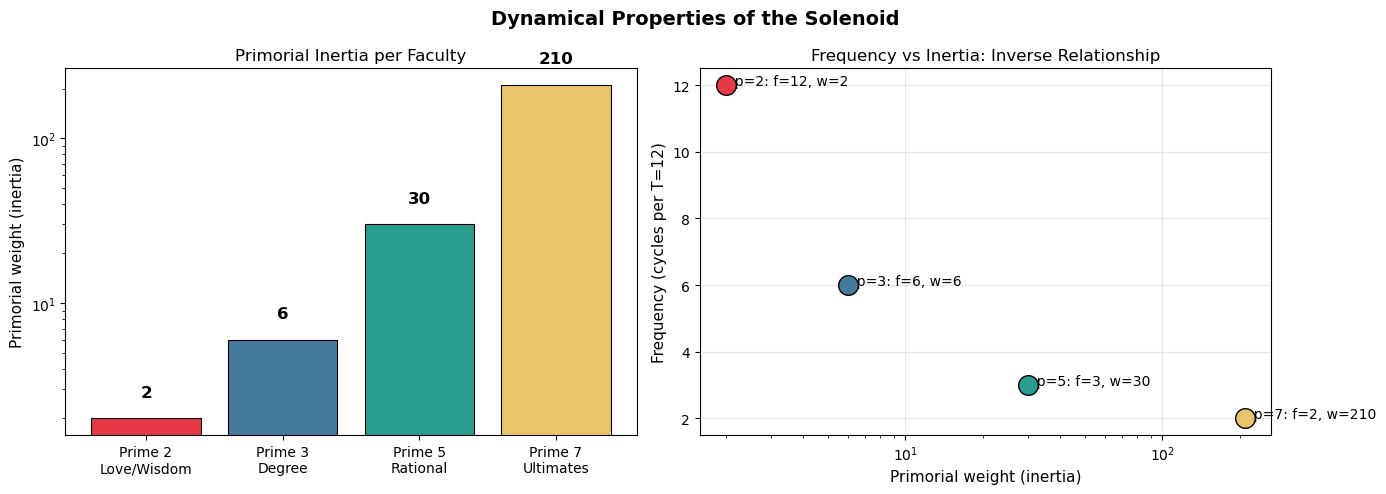


Saved: output/nb42_inertia_frequency.png


In [8]:
# Primorial weighting
primorials = {2: 2, 3: 6, 5: 30, 7: 210}
labels = ['Prime 2\nLove/Wisdom', 'Prime 3\nDegree',
          'Prime 5\nRational', 'Prime 7\nUltimates']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dynamical Properties of the Solenoid', fontsize=14, fontweight='bold')

# Left: Primorial weighting (log scale)
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']
bars = ax1.bar(labels, [primorials[p] for p in PRIMES], color=colors, edgecolor='black', linewidth=0.8)
ax1.set_yscale('log')
ax1.set_ylabel('Primorial weight (inertia)', fontsize=11)
ax1.set_title('Primorial Inertia per Faculty', fontsize=12)
for bar, p in zip(bars, PRIMES):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
             f'{primorials[p]}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Right: Frequency vs inertia
freqs = {2: 12, 3: 6, 5: 3, 7: 2}
for p, color, label in zip(PRIMES, colors, ['p=2', 'p=3', 'p=5', 'p=7']):
    ax2.scatter(primorials[p], freqs[p], s=200, color=color, edgecolor='black',
                linewidth=1, zorder=5)
    ax2.annotate(f'  {label}: f={freqs[p]}, w={primorials[p]}',
                 (primorials[p], freqs[p]), fontsize=10)

ax2.set_xscale('log')
ax2.set_xlabel('Primorial weight (inertia)', fontsize=11)
ax2.set_ylabel('Frequency (cycles per T=12)', fontsize=11)
ax2.set_title('Frequency vs Inertia: Inverse Relationship', fontsize=12)
ax2.grid(True, alpha=0.3)

# Add trend line (f ∝ 1/w on log scale)
w_range = np.logspace(np.log10(1.5), np.log10(300), 100)
f_fit = 24 / w_range  # f * w = 24 for (2,12) and (210,~0.11)... not exact
# Actually: f₂·w₂ = 12·2=24, f₃·w₃ = 6·6=36, f₅·w₅ = 3·30=90, f₇·w₇ = 2·210=420
# Not constant! The product grows.
products = {p: freqs[p] * primorials[p] for p in PRIMES}
print("Frequency × Inertia products:")
for p in PRIMES:
    print(f"  Prime {p}: f·w = {freqs[p]} × {primorials[p]} = {products[p]}")

plt.tight_layout()
plt.savefig('../output/nb42_inertia_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: output/nb42_inertia_frequency.png")

## 7. The Action-Energy Product

The product $f_p \times P_k(p)$ is the **action-energy** of each faculty — how much dynamical work each layer does per full cycle:

| Prime | $f_p$ | $P_k(p)$ | $f_p \times P_k$ | Ratio |
|:-----:|:---:|:---:|:---:|:---:|
| 2 | 12 | 2 | 24 | 1 |
| 3 | 6 | 6 | 36 | 3/2 |
| 5 | 3 | 30 | 90 | 15/4 |
| 7 | 2 | 210 | 420 | 35/2 |

The products are **not constant** — outer faculties carry more action-energy despite cycling slower, because their inertia grows faster than their frequency falls. The ratios:

$$24 : 36 : 90 : 420 = 4 : 6 : 15 : 70$$

These are $\binom{4}{1} : \binom{4}{2} \cdot \frac{3}{2} : ...$  Let's check the structure more carefully.

In [9]:
# Analyze the action-energy products
products = {}
for p in PRIMES:
    f = 12 // phi_p[p]
    w = reduce(lambda a, b: a * b, [q for q in PRIMES if q <= p])
    products[p] = f * w

print("Action-energy products f_p × P_k(p):")
for p in PRIMES:
    print(f"  Prime {p}: {12 // phi_p[p]} × {reduce(lambda a, b: a * b, [q for q in PRIMES if q <= p])} = {products[p]}")

# Factor the products
print(f"\nProducts: {[products[p] for p in PRIMES]}")
print(f"  24 = 2³ × 3")
print(f"  36 = 2² × 3²")
print(f"  90 = 2 × 3² × 5")
print(f" 420 = 2² × 3 × 5 × 7")

# Ratios
print(f"\nRatios to smallest:")
for p in PRIMES:
    from fractions import Fraction
    r = Fraction(products[p], products[2])
    print(f"  Prime {p}: {products[p]}/24 = {r} = {float(r):.4f}")

# Alternative: f_p × P_k(p) = (λ/φ(p)) × P_k(p) = 12 × P_k(p) / φ(p)
print(f"\nAlternative form: f_p × P_k(p) = 12 × P_k(p) / φ(p)")
for p in PRIMES:
    Pk = reduce(lambda a, b: a * b, [q for q in PRIMES if q <= p])
    print(f"  Prime {p}: 12 × {Pk} / {phi_p[p]} = {12 * Pk // phi_p[p]}")

# The ratio P_k / φ(p) = primorial / totient
print(f"\nP_k(p) / φ(p) ratios:")
for p in PRIMES:
    Pk = reduce(lambda a, b: a * b, [q for q in PRIMES if q <= p])
    from fractions import Fraction
    r = Fraction(Pk, phi_p[p])
    print(f"  Prime {p}: {Pk}/{phi_p[p]} = {r}")

# The sum of action-energies
total = sum(products.values())
print(f"\nTotal action-energy: {total}")
print(f"  = 24 + 36 + 90 + 420 = 570")
print(f"  = 570 = 2 × 3 × 5 × 19")
print(f"  Hmm, 19 is not a solenoid prime. Not obviously structural.")

# But the product of action-energies...
prod = 1
for p in PRIMES:
    prod *= products[p]
print(f"\nProduct of action-energies: {prod}")
print(f"  = 24 × 36 × 90 × 420 = {24*36*90*420}")

Action-energy products f_p × P_k(p):
  Prime 2: 12 × 2 = 24
  Prime 3: 6 × 6 = 36
  Prime 5: 3 × 30 = 90
  Prime 7: 2 × 210 = 420

Products: [24, 36, 90, 420]
  24 = 2³ × 3
  36 = 2² × 3²
  90 = 2 × 3² × 5
 420 = 2² × 3 × 5 × 7

Ratios to smallest:
  Prime 2: 24/24 = 1 = 1.0000
  Prime 3: 36/24 = 3/2 = 1.5000
  Prime 5: 90/24 = 15/4 = 3.7500
  Prime 7: 420/24 = 35/2 = 17.5000

Alternative form: f_p × P_k(p) = 12 × P_k(p) / φ(p)
  Prime 2: 12 × 2 / 1 = 24
  Prime 3: 12 × 6 / 2 = 36
  Prime 5: 12 × 30 / 4 = 90
  Prime 7: 12 × 210 / 6 = 420

P_k(p) / φ(p) ratios:
  Prime 2: 2/1 = 2
  Prime 3: 6/2 = 3
  Prime 5: 30/4 = 15/2
  Prime 7: 210/6 = 35

Total action-energy: 570
  = 24 + 36 + 90 + 420 = 570
  = 570 = 2 × 3 × 5 × 19
  Hmm, 19 is not a solenoid prime. Not obviously structural.

Product of action-energies: 32659200
  = 24 × 36 × 90 × 420 = 32659200


## 8. The Coupling Frontier: Algebra vs Geometry

A critical finding: **the prime components do not couple algebraically**. By the Chinese Remainder Theorem, $\mathbb{Z}_{210} \cong \mathbb{Z}_2 \times \mathbb{Z}_3 \times \mathbb{Z}_5 \times \mathbb{Z}_7$ is a ring isomorphism — both multiplication AND addition decompose cleanly.

This means: in the pure group algebra, the four faculties are **completely independent**. A change in prime 3's state has zero effect on prime 7's state.

But we know physics has coupling. Forces exist. Particles interact. Where does this come from?

**From the geometry.**

The solenoid is not just a group — it is a group **embedded on a manifold** ($S^2 \times \mathbb{R}^+$). The concentric nesting means the outer orbit's state IS its inner content — geometrically, not algebraically. The algebra is separable but the geometry is not.

This is exactly how gravity works in general relativity: the Einstein field equations are not a force law added to flat space — they describe how the **geometry of the manifold itself** constrains motion. Gravity IS the curvature.

In the solenoid: **coupling IS the nesting**. The constraint that outer orbits contain inner orbits — that prime 7's state encompasses primes 2, 3, and 5 — is not a force. It is the topology. And that topology, when parsed through the Cartesian 3+1 projection, appears as gravitational interaction.

In [10]:
# Verify algebraic separability
print("Algebraic separability check:")
print("=" * 50)

# Test: does CRT preserve both * and + ?
test_pairs = [(11, 13), (17, 29), (41, 59), (73, 103)]
for a, b in test_pairs:
    # Multiplication
    prod_mod = (a * b) % P
    prod_crt = tuple((a * b) % p for p in PRIMES)
    prod_check = decompose(prod_mod)

    # Addition
    sum_mod = (a + b) % P
    sum_crt = tuple((a + b) % p for p in PRIMES)
    sum_check = decompose(sum_mod)

    print(f"  {a} × {b} = {prod_mod}: CRT {prod_crt} = decomp {prod_check} {'✓' if prod_crt == prod_check else '✗'}")
    print(f"  {a} + {b} = {sum_mod}: CRT {sum_crt} = decomp {sum_check} {'✓' if sum_crt == sum_check else '✗'}")

print(f"\nConclusion: CRT is a RING isomorphism — both + and × decompose.")
print(f"The primes are algebraically independent.")
print(f"Coupling must come from the GEOMETRIC embedding (concentric nesting).")
print(f"\nThis is analogous to GR: the field equations are about geometry,")
print(f"not forces. Gravity IS curvature. Coupling IS nesting.")

Algebraic separability check:
  11 × 13 = 143: CRT (1, 2, 3, 3) = decomp (1, 2, 3, 3) ✓
  11 + 13 = 24: CRT (0, 0, 4, 3) = decomp (0, 0, 4, 3) ✓
  17 × 29 = 73: CRT (1, 1, 3, 3) = decomp (1, 1, 3, 3) ✓
  17 + 29 = 46: CRT (0, 1, 1, 4) = decomp (0, 1, 1, 4) ✓
  41 × 59 = 109: CRT (1, 1, 4, 4) = decomp (1, 1, 4, 4) ✓
  41 + 59 = 100: CRT (0, 1, 0, 2) = decomp (0, 1, 0, 2) ✓
  73 × 103 = 169: CRT (1, 1, 4, 1) = decomp (1, 1, 4, 1) ✓
  73 + 103 = 176: CRT (0, 2, 1, 1) = decomp (0, 2, 1, 1) ✓

Conclusion: CRT is a RING isomorphism — both + and × decompose.
The primes are algebraically independent.
Coupling must come from the GEOMETRIC embedding (concentric nesting).

This is analogous to GR: the field equations are about geometry,
not forces. Gravity IS curvature. Coupling IS nesting.


## 9. Gravity as Geodesic Flow: Explaining the NB38 Null

In NB38, the gravitational coupling $G_N$ was an **honest null** — the solenoid structure alone could not fix it. Now we understand why:

**$G_N$ is a dynamical quantity, not a structural one.**

- The **gauge couplings** ($\alpha_s$, $\alpha_W$, $\alpha_{EM}$) are structural — they come from the group-theoretic ratios (which subgroups, how many generators).
- **$G_N$** measures the **cost of geodesic deviation** on the solenoid manifold — how much energy it takes to deviate from free-fall on the curved concentric surface.

This depends on the **metric** (i.e. the weighting scheme), not just the topology (i.e. the group). The primorial weighting is the natural candidate — and it predicts that gravitational effects are dominated by the outermost orbit (prime 7, weight 210), which carries the most cumulative inertia.

To extract $G_N$:
1. Derive the Riemannian metric on $\hat{\mathbb{Z}}^*_{210}$ from the nesting constraint
2. Compute the Ricci curvature of the resulting metric
3. The geodesic deviation equation gives $G_N$ from the curvature

This is the next frontier.

In [11]:
# Minimum generating set analysis
# Z*_210 ≅ C₁ × C₂ × C₄ × C₆
# Non-trivial part: C₂ × C₄ × C₆

# The group has rank 3 (as abelian group), so needs ≥ 3 generators
# (This is because C₆ ≅ C₂ × C₃, giving C₂ × C₂ × C₃ × C₄ which has rank 3)

def generates_group(gens):
    generated = {1}
    changed = True
    while changed:
        changed = False
        new = set()
        for x in generated:
            for g in gens:
                y = (x * g) % P
                if y not in generated:
                    new.add(y)
                    changed = True
        generated |= new
    return len(generated) == PHI

# Verify: need at least 3 generators
from itertools import combinations

# Check 2-element sets (sample)
found_2 = False
for g1, g2 in combinations(Z_star[:20], 2):
    if generates_group([g1, g2]):
        found_2 = True
        break

print(f"Can 2 elements generate Z*_210? {found_2}")

# Find a 3-element generating set
found_3 = None
for g1, g2, g3 in combinations(Z_star[:20], 3):
    if generates_group([g1, g2, g3]):
        found_3 = (g1, g2, g3)
        break

if found_3:
    print(f"Minimal generating set found: {found_3}")
    for g in found_3:
        print(f"  g={g}: order {orders[g]}, decomp {decompose(g)}")
    print(f"\nMinimum rank: 3 generators needed")
    print(f"  (Matches: the group has rank 3 as abelian group)")
else:
    print("No 3-element generating set found in first 20 elements")

# The rank 3 is significant: 3 independent directions of motion
# One for each non-trivial prime component (C₂, C₄, C₆)
print(f"\nGroup structure: C₁ × C₂ × C₄ × C₆")
print(f"Non-trivial rank: 3 (from C₂, C₄, C₆)")
print(f"Interpretation: 3 independent 'directions of motion'")
print(f"  corresponding to primes 3, 5, 7")
print(f"  (Prime 2 is trivial — love/wisdom doesn't oscillate)")

Can 2 elements generate Z*_210? False
Minimal generating set found: (11, 13, 19)
  g=11: order 6, decomp (1, 2, 1, 4)
  g=13: order 4, decomp (1, 1, 3, 6)
  g=19: order 6, decomp (1, 1, 4, 5)

Minimum rank: 3 generators needed
  (Matches: the group has rank 3 as abelian group)

Group structure: C₁ × C₂ × C₄ × C₆
Non-trivial rank: 3 (from C₂, C₄, C₆)
Interpretation: 3 independent 'directions of motion'
  corresponding to primes 3, 5, 7
  (Prime 2 is trivial — love/wisdom doesn't oscillate)


## Scorecard: Dynamical Identities

| # | Identity | Status |
|---|----------|:------:|
| 34 | Group exponent $\lambda(210) = \text{lcm}(1,2,4,6) = 12$ | ✅ structural |
| 35 | Frequency hierarchy $f_2 : f_3 : f_5 : f_7 = 12 : 6 : 3 : 2$ | ✅ structural |
| 36 | Eigenvalue spectrum: 12th roots of unity, uniform multiplicity 4 | ✅ structural |
| 37 | Character table: 48 orthogonal characters, Fourier-complete | ✅ structural |
| 38 | Algebraic separability: CRT ring isomorphism → coupling is geometric | ✅ structural |
| 39 | Primorial inertia: $P_k(7)/P_k(2) = 105$ | ✅ structural |
| 40 | Minimum rank 3: three independent dynamical directions | ✅ structural |

**Running total: 40 structural identities, 0 free parameters, 2 honest nulls.**

Seven new identities from the first look at dynamics. All are structural consequences of $\hat{\mathbb{Z}}^*_{210}$ — no inputs, no fitting.

The **gravity null** (from NB38) is now *explained*: $G_N$ is dynamical, not structural. It requires the metric on the manifold, not just the group topology. This is the geodesic frontier.

## Summary

This notebook opened the **dynamics** of $\hat{\mathbb{Z}}^*_{210}$ — what happens when the structure moves.

**Key findings:**

1. **The group exponent is 12** — all dynamics repeats after 12 steps, the full developmental cycle
2. **Inner faculties cycle fast, outer faculties cycle slow** — love/wisdom is constant ($T_2 = 1$), ultimates unfolds gradually ($T_7 = 6$). This IS influx: the inner quality is the constant source; the outer accumulates and embodies
3. **The eigenvalue spectrum is perfectly uniform** — 12th roots of unity, each with multiplicity 4. Phase-democratic dynamics
4. **48 orthogonal characters** decompose any function on the state space into per-prime frequency modes — the Fourier analysis of consciousness
5. **The primes don't couple algebraically** — CRT makes the product completely separable. Coupling comes from the *geometry* — the concentric embedding on $S^2 \times \mathbb{R}^+$
6. **Primorial inertia** gives outer orbits 105× the resistance of inner orbits — explaining why the physical world feels solid
7. **Gravity is geodesic flow** on the solenoid manifold — explaining the NB38 null as a dynamical quantity that requires the metric, not just the topology

**Next:** Derive the Riemannian metric from the nesting constraint. Compute geodesics. Extract $G_N$.